Random Forest - MAE: 0.30, RMSE: 0.42, R2: 0.9988
Linear Regression - MAE: 0.41, RMSE: 0.47, R2: 0.9985
              feature  importance
6       avg_vibration    0.307975
2          energy_kwh    0.188002
5    avg_pump_current    0.178149
0         temperature    0.148304
4  avg_pump_speed_rpm    0.124130
1            pressure    0.052556
3      downtime_hours    0.000884


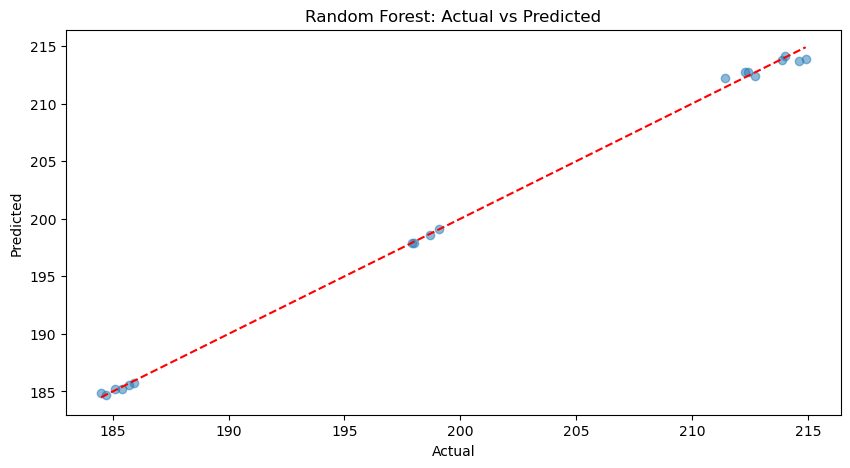

{'ResponseMetadata': {'RequestId': '18B2C854184BFAF4',
  'HostId': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'accept-ranges': 'bytes',
   'content-length': '0',
   'etag': '"c8c3accb67dc0356e23f061e6cecb429"',
   'server': 'MinIO',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'vary': 'Origin, Accept-Encoding',
   'x-amz-checksum-crc32': 'BnYb3Q==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'x-amz-id-2': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
   'x-amz-request-id': '18B2C854184BFAF4',
   'x-content-type-options': 'nosniff',
   'x-ratelimit-limit': '1964',
   'x-ratelimit-remaining': '1964',
   'x-xss-protection': '1; mode=block',
   'date': 'Mon, 25 May 2026 10:31:06 GMT'},
  'RetryAttempts': 0},
 'ETag': '"c8c3accb67dc0356e23f061e6cecb429"',
 'ChecksumCRC32': 'BnYb3Q==',
 'ChecksumType': 'FULL_OBJECT'}

In [1]:
# 04_ml_forecast.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import boto3
from botocore.client import Config
import io
import pickle

s3 = boto3.client('s3', endpoint_url='http://minio:9000', aws_access_key_id='minioadmin', aws_secret_access_key='minioadmin123', config=Config(signature_version='s3v4'))

def read(key):
    resp = s3.get_object(Bucket='oil-data-lake', Key=key)
    return pd.read_parquet(io.BytesIO(resp['Body'].read()))

ml_data = read('processed/ml_dataset.parquet')
ml_data = ml_data[ml_data['status'] == 'active'].dropna()

features = ['temperature', 'pressure', 'energy_kwh', 'downtime_hours', 'avg_pump_speed_rpm', 'avg_pump_current', 'avg_vibration']
target = 'daily_oil_ton'

X = ml_data[features]
y = ml_data[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)

print(f'Random Forest - MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}, R2: {r2_score(y_test, y_pred_rf):.4f}')
print(f'Linear Regression - MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}, R2: {r2_score(y_test, y_pred_lr):.4f}')

importance = pd.DataFrame({'feature': features, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
print(importance)

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest: Actual vs Predicted')
plt.savefig('ml_predictions.png')
plt.show()

buf = io.BytesIO()
pickle.dump(rf, buf)
buf.seek(0)
s3.put_object(Bucket='oil-data-lake', Key='models/rf_model.pkl', Body=buf.getvalue())